In [38]:
!pip install --upgrade torch==2.6.0

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [1]:
# Install once in a notebook:
# !pip install transformers py3Dmol accelerate

import torch
import py3Dmol

from transformers import AutoTokenizer, EsmForProteinFolding
from transformers.models.esm.openfold_utils.feats import atom14_to_atom37
from transformers.models.esm.openfold_utils.protein import Protein as OFProtein
from transformers.models.esm.openfold_utils.protein import to_pdb


def outputs_to_pdb(outputs) -> list[str]:
    """Convert an EsmForProteinFolding output into PDB-formatted strings."""

    # positions contains coordinates from every recycling iteration.
    # Use the final iteration, then convert atom14 coordinates to atom37.
    final_atom_positions = atom14_to_atom37(
        outputs.positions[-1],
        outputs,
    )

    final_atom_positions = final_atom_positions.detach().cpu().numpy()

    # Move the other required tensors to NumPy.
    output_data = {
        key: value.detach().cpu().numpy()
        for key, value in outputs.items()
        if torch.is_tensor(value)
    }

    pdb_strings = []

    for batch_index in range(output_data["aatype"].shape[0]):
        protein = OFProtein(
            aatype=output_data["aatype"][batch_index],
            atom_positions=final_atom_positions[batch_index],
            atom_mask=output_data["atom37_atom_exists"][batch_index],
            residue_index=output_data["residue_index"][batch_index] + 1,
            b_factors=output_data["plddt"][batch_index],
            chain_index=(
                output_data["chain_index"][batch_index]
                if "chain_index" in output_data
                else None
            ),
        )

        pdb_strings.append(to_pdb(protein))

    return pdb_strings


# -------------------------
# Load ESMFold
# -------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "facebook/esmfold_v1"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = EsmForProteinFolding.from_pretrained(
    model_name,
    low_cpu_mem_usage=True,
).to(device)

model.eval()

sequence = "MLKNVQVQLV"

inputs = tokenizer(
    [sequence],
    return_tensors="pt",
    add_special_tokens=False,
)

inputs = {key: value.to(device) for key, value in inputs.items()}

# -------------------------
# Predict the structure
# -------------------------

with torch.no_grad():
    outputs = model(**inputs)

folded_positions = outputs.positions

# Convert prediction into PDB format.
pdb_string = outputs_to_pdb(outputs)[0]

# Save the predicted structure.
with open("predicted_structure.pdb", "w") as pdb_file:
    pdb_file.write(pdb_string)

# -------------------------
# Display the 3D structure
# -------------------------

viewer = py3Dmol.view(width=800, height=600)

viewer.addModel(pdb_string, "pdb")
viewer.setStyle(
    {
        "cartoon": {
            # PDB B-factors contain the predicted pLDDT confidence.
            "colorscheme": {
                "prop": "b",
                "gradient": "roygb",
                "min": 50,
                "max": 90,
            }
        }
    }
)

viewer.setBackgroundColor("white")
viewer.zoomTo()
viewer.show()

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 4498/4498 [00:04<00:00, 902.16it/s] 
[transformers] EsmForProteinFolding LOAD REPORT from: facebook/esmfold_v1
Key                                | Status  | 
-----------------------------------+---------+-
esm.contact_head.regression.weight | MISSING | 
esm.contact_head.regression.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [1]:
import numpy as np
import bsf
import esm
import torch
import einops

In [30]:
!wget https://ftp.ensembl.org/pub/release-116/fasta/homo_sapiens/pep/Homo_sapiens.GRCh38.pep.all.fa.gz
!gunzip Homo_sapiens.GRCh38.pep.all.fa.gz

--2026-07-10 16:13:07--  https://ftp.ensembl.org/pub/release-116/fasta/homo_sapiens/pep/Homo_sapiens.GRCh38.pep.all.fa.gz
Resolving ftp.ensembl.org (ftp.ensembl.org)... 193.62.193.169
Connecting to ftp.ensembl.org (ftp.ensembl.org)|193.62.193.169|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23319936 (22M) [application/x-gzip]
Saving to: ‘Homo_sapiens.GRCh38.pep.all.fa.gz’

Homo_sapiens.GRCh38 100%[===================>]  22.24M  61.6MB/s    in 0.4s    

2026-07-10 16:13:08 (61.6 MB/s) - ‘Homo_sapiens.GRCh38.pep.all.fa.gz’ saved [23319936/23319936]



In [2]:
def load_fasta_as_dict(fasta_path, max_length=1024, min_length=100):
    proteins = {}
    current_header = None
    current_sequence = []

    with open(fasta_path, "r") as fasta_file:
        for line in fasta_file:
            line = line.strip()

            if not line:
                continue

            if line.startswith(">"):
                # Save the previous sequence
                if current_header is not None:
                    sequence = "".join(current_sequence)

                    if len(sequence) <= max_length:
                        if len(sequence) >= min_length:
                            proteins[current_header] = sequence

                current_header = line[1:]
                current_sequence = []

            else:
                current_sequence.append(line)

        # Save the final sequence
        if current_header is not None:
            sequence = "".join(current_sequence)

            if len(sequence) <= max_length:
                if len(sequence) >= min_length:
                    proteins[current_header] = sequence

    return proteins

In [6]:
fasta_path = "../../Homo_sapiens.GRCh38.pep.all.fa"
all_proteins = load_fasta_as_dict(fasta_path)
tenk_proteins = dict(list(all_proteins.items())[:1000])

In [7]:
standard_amino_acids = set("ACDEFGHIKLMNPQRSTVWY")

ten_proteins = {
    protein_id: "".join(
        aa for aa in sequence.upper()
        if aa in standard_amino_acids
    )
    for protein_id, sequence in tenk_proteins.items()
}

In [8]:
# Load ESM-2 model
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

model = model.to(device)

print("model load successfull")



Using: cuda
model load successfull


In [9]:
all_data = list(ten_proteins.items())

sequence_representations = []
seq_chunk_dict = {}
tokens_total = 0
batch = 0

batch_size = 128
for start in range(0, len(all_data), batch_size):
    batch += 1
    print('batch:', batch)
    batch_data = all_data[start : start + batch_size]
    batch_labels, batch_strs, batch_tokens = batch_converter(batch_data)
    batch_lens = (batch_tokens != alphabet.padding_idx).sum(1)

    batch_tokens = batch_tokens.to(device)


    # Extract per-residue representations (on CPU)
    with torch.no_grad():
        results = model(batch_tokens, repr_layers=[33], return_contacts=False)
    token_representations = results["representations"][33]

    # NOTE: token 0 is always a beginning-of-sequence token, so the first residue is token 1.

    for i, tokens_len in enumerate(batch_lens): # Generate per-sequence representations via averagingk
        seq_chunk_dict[batch_labels[i]] = (tokens_total, tokens_total + (tokens_len.item() - 2))
        tokens_total += (tokens_len.item() - 2)
        res_representations = token_representations[i, 1 : tokens_len - 1].detach().cpu()
        sequence_representations.append(res_representations)

sequence_representations = torch.cat(sequence_representations, dim = 0)

batch: 1
batch: 2
batch: 3
batch: 4
batch: 5
batch: 6
batch: 7
batch: 8


In [10]:
norm_sequence_representations = sequence_representations - sequence_representations.mean(dim=0)
x = norm_sequence_representations
x = (x / np.sqrt((x**2).sum(1).mean()))*(np.sqrt(x.shape[1]))
x = x.cuda()

In [11]:
model = bsf.GrassmannianBSF(d=x.shape[1], n_groups=256, group_size=3, l0=8)
bsf.train(model, x, epochs=300, lr=3e-3)

epoch   1/300   loss=0.4864   R2=0.6151   L0=8.0   dead=0/256
epoch   5/300   loss=0.3359   R2=0.6691   L0=8.0   dead=0/256
epoch  10/300   loss=0.3262   R2=0.6748   L0=8.0   dead=0/256
epoch  15/300   loss=0.3238   R2=0.6778   L0=8.0   dead=0/256
epoch  20/300   loss=0.3227   R2=0.6776   L0=8.0   dead=0/256
epoch  25/300   loss=0.3220   R2=0.6799   L0=8.0   dead=0/256
epoch  30/300   loss=0.3215   R2=0.6806   L0=8.0   dead=0/256
epoch  35/300   loss=0.3211   R2=0.6831   L0=8.0   dead=0/256
epoch  40/300   loss=0.3209   R2=0.6803   L0=8.0   dead=0/256
epoch  45/300   loss=0.3206   R2=0.6793   L0=8.0   dead=0/256
epoch  50/300   loss=0.3204   R2=0.6816   L0=8.0   dead=0/256
epoch  55/300   loss=0.3203   R2=0.6818   L0=8.0   dead=0/256
epoch  60/300   loss=0.3201   R2=0.6825   L0=8.0   dead=0/256
epoch  65/300   loss=0.3199   R2=0.6827   L0=8.0   dead=0/256
epoch  70/300   loss=0.3198   R2=0.6800   L0=8.0   dead=0/256
epoch  75/300   loss=0.3197   R2=0.6814   L0=8.0   dead=0/256
epoch  8

GrassmannianBSF()

In [12]:
# Encode every patch -> (N, G, K) codes; atoms are the decoder blocks (G, K, d).
device = next(model.parameters()).device
z = model.encode(torch.as_tensor(x, dtype=torch.float32, device=device)).detach().cpu().numpy()
atoms = model.atoms().cpu().numpy()

# Rank concepts by total energy; keep ones that fire enough.
heat = np.linalg.norm(z, axis=-1)
fire = (heat > 1e-6).sum(0)
energy = (heat ** 2).sum(0)
top = [g for g in np.argsort(-energy) if fire[g] >= 100][:20]
print('top concepts:', top)

top concepts: [187, 172, 13, 236, 76, 220, 168, 139, 100, 51, 173, 137, 70, 140, 240, 229, 110, 121, 78, 116]


In [13]:
import math
import numpy as np
import matplotlib.pyplot as plt
import bsf


def plot_manifolds_only(
    z,
    atoms,
    concepts,
    ncols=4,
    max_points=5000,
    clip=98.0,
    point_size=4.0,
    drop_low_norm=0.0,
    saturation=1.0,
):
    """
    Plot only the 3D PCA manifold for each BSF concept.

    z:        (N, G, K) BSF codes
    atoms:    (G, K, d) decoder atoms
    concepts: iterable of concept indices
    """
    concepts = list(concepts)
    nrows = math.ceil(len(concepts) / ncols)

    fig = plt.figure(figsize=(4 * ncols, 4 * nrows))
    heat = np.linalg.norm(z, axis=-1)  # (N, G)

    for j, g in enumerate(concepts):
        ax = fig.add_subplot(nrows, ncols, j + 1, projection="3d")

        # Examples where this concept is active.
        idx = np.flatnonzero(heat[:, g] > 1e-6)

        # Optionally discard the weakest active points.
        if drop_low_norm > 0 and idx.size > 8:
            threshold = np.quantile(heat[idx, g], drop_low_norm)
            idx = idx[heat[idx, g] >= threshold]

        if idx.size < 8:
            ax.set_axis_off()
            ax.set_title(f"Concept {g}: too few points")
            continue

        # Limit very large clouds.
        if idx.size > max_points:
            idx = np.random.choice(idx, max_points, replace=False)

        # Reconstruct this concept's contribution in activation space.
        contributions = z[idx, g, :] @ atoms[g]  # (points, d)

        # PCA-project the contribution cloud to three dimensions.
        mean, components = bsf.viz.pca_fit(contributions, k=3)
        projected = (contributions - mean) @ components.T

        # Match the repo's outlier clipping and colorization.
        projected = bsf.viz.radial_clip(projected, pct=clip)
        colorize = bsf.viz.make_colorize(
            projected,
            per_axis=False,
            saturation=saturation,
        )

        bsf.viz.manifold_ax(
            ax,
            projected,
            colorize(projected),
            point_size=point_size,
        )

        ax.set_title(
            f"Concept {g}\n{idx.size} active points",
            pad=0,
        )

    # Hide unused subplot positions.
    total_slots = nrows * ncols
    for j in range(len(concepts), total_slots):
        ax = fig.add_subplot(nrows, ncols, j + 1)
        ax.set_axis_off()

    fig.tight_layout()
    return fig

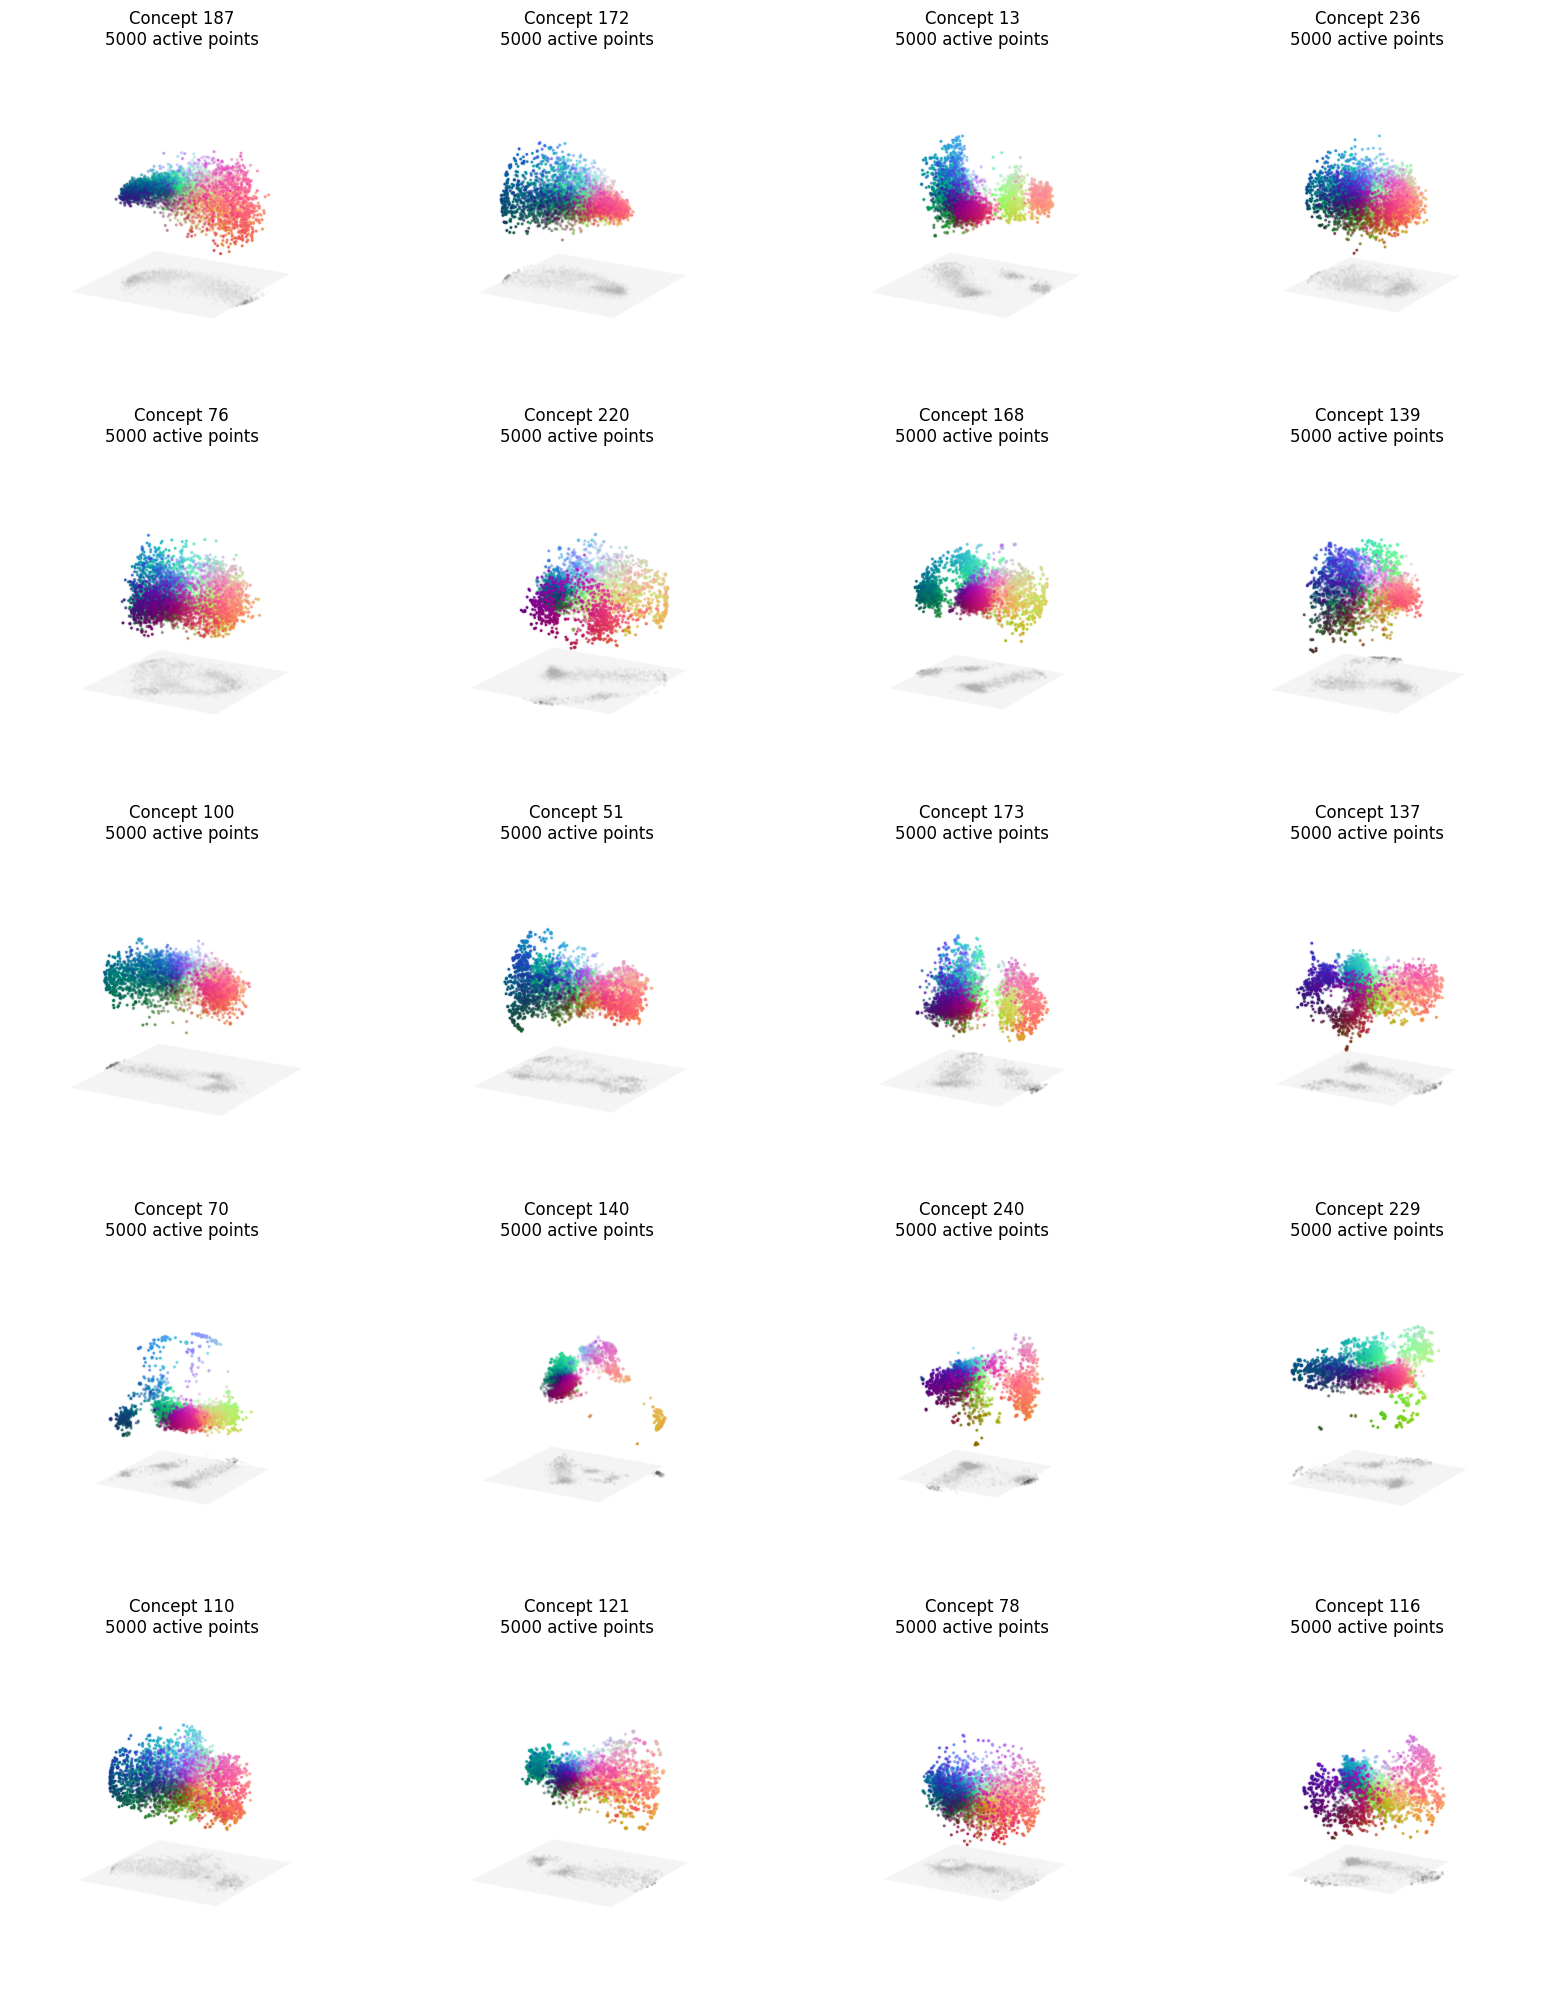

In [14]:
fig = plot_manifolds_only(
    z,
    atoms,
    top,
    ncols=4,
    point_size=4,
)

plt.show()